In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/yash934/research-paper-topic-discovery/cleaned_arxiv_full.csv
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/__results__.html
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/__notebook__.ipynb
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/__output__.json
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/custom.css
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/__results___files/__results___6_1.png
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/__results___files/__results___7_2.png
/kaggle/input/notebooks/yash934/research-paper-topic-discovery/__results___files/__results___8_2.png
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_feature_names.pkl
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_vocab.json
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__results__.html
/kaggle/input/notebooks/aryanna

In [2]:
import pandas as pd
import numpy as np
import pickle
from scipy import sparse
from sklearn.decomposition import MiniBatchNMF
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Loading TF-IDF matrix and feature names...")

input_path = r"/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/"

# Load the sparse matrix
tfidf_matrix = sparse.load_npz(input_path + "tfidf_features.npz")

# Load the feature names (vocabulary)
with open(input_path + "tfidf_feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")
print(f"Number of Features: {len(feature_names)}")

Loading TF-IDF matrix and feature names...
TF-IDF Matrix Shape: (2968855, 10000)
Number of Features: 10000


In [4]:
num_topics = 20

print(f"Training MiniBatchNMF model with {num_topics} latent topics...")

nmf_model = MiniBatchNMF(
    n_components=num_topics, 
    random_state=42, 
    batch_size=1024, 
    max_iter=200
)

# W is the Document-Topic matrix (Papers x Topics)
W = nmf_model.fit_transform(tfidf_matrix)

# H is the Topic-Word matrix (Topics x Words)
H = nmf_model.components_

print("Model training complete!")

Training MiniBatchNMF model with 20 latent topics...
Model training complete!


Matrix $W$ (Document-Topic): This becomes a matrix of shape (2,968,855 $\times$ 20). For every single paper, it calculates 20 numbers. These numbers represent how strongly that specific paper belongs to each of the 20 latent topics.

Matrix $H$ (Topic-Word): This becomes a matrix of shape (20 $\times$ 10,000). This tells the model which specific vocabulary words define each of those 20 blank topics.
The non-negativity constraint (no negative numbers allowed) forces the model to look for additive features, which naturally creates highly interpretable clusters of co-occurring words.

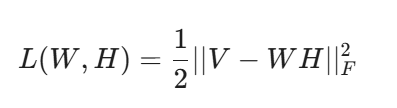

FORBENIUS NORM

MiniBatchNMF changes the optimization math to use Stochastic Gradient Descent (SGD) principles.

Standard NMF requires full-batch matrix multiplication(Standard NMF calculates $W^T V$ and $V H^T$ using the entire 2.96 million rows at once), which causes memory exhaustion on a dataset of 3 million documents. MiniBatchNMF caps our memory usage by only processing 1,024 documents at a time using stochastic updates

Mathematically, the constraint is simply:$$W \ge 0 \quad \text{and} \quad H \ge 0$$If we used Singular Value Decomposition (SVD) or Principal Component Analysis (PCA), the resulting matrices would contain negative numbers. In text, a negative number implies a document "subtracts" a concept, which makes no intuitive sense. By forcing all values to be positive or zero, NMF ensures a "parts-based representation." A document must be built by adding topics together, making the resulting matrices highly interpretable

In [5]:
def display_topics(model, feature_names, no_top_words):
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-no_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        
        print(f"Topic {topic_idx}: " + " | ".join(top_words))
        topic_dict[topic_idx] = top_words
        
    return topic_dict

print("Top 15 words per latent topic:\n")
topics = display_topics(nmf_model, feature_names, 15)

Top 15 words per latent topic:

Topic 0: result | model | time | study | present | large | effect | high | order | different | parameter | provide | temperature | non | process
Topic 1: llm | task | algorithm | propose | learning | datum | model | performance | dataset | method | learn | training | base | language | approach
Topic 2: prove | problem | space | operator | function | polynomial | equation | theorem | solution | set | condition | paper | class | case | bound
Topic 3: star | galaxy | mass | stellar | cluster | formation | disk | gas | redshift | dwarf | velocity | survey | population | observation | luminosity
Topic 4: graph | vertex | quantum | edge | number | state | qubit | algorithm | optical | entanglement | cluster | subgraph | degree | gate | path
Topic 5: algebra | group | category | module | representation | lie | structure | action | ring | let | algebras | topological | language | finite | invariant
Topic 6: quantum | classical | qubit | circuit | entanglement | 

In [ ]:
topic_mapping = {
    0: "General Physics & Experimental Research",    # result, model, time, temperature, process
    1: "Large Language Models & Machine Learning",   # llm, task, training, language, dataset
    2: "Mathematical Analysis & Proofs",             # prove, theorem, polynomial, equation, bound
    3: "Astrophysics & Stellar Formation",           # star, galaxy, redshift, dwarf, luminosity
    4: "Graph Theory & Quantum Algorithms",          # graph, vertex, edge, qubit, entanglement
    5: "Abstract Algebra & Topology",                # algebra, group, module, ring, invariant
    6: "Quantum Information & Computing",            # quantum, qubit, circuit, photon, computing
    7: "Particle Physics & High Energy",             # decay, quark, higgs, boson, lhc, collision
    8: "General Relativity & Cosmology",             # gravity, field, cosmological, einstein, spacetime
    9: "Optics & High-Energy Detectors",             # ray, photon, laser, gamma, jet, detector
    10: "Quantum Field Theory & Electromagnetism",   # magnetic, gauge, symmetry, chiral, fermion
    11: "Computer Vision & Deep Learning",           # image, segmentation, feature, cnn, neural
    12: "Network Dynamics & Systems",                # network, node, dynamic, flow, layer, link
    13: "Orbital Dynamics & Neutron Stars",          # hole, black, orbit, binary, neutron, planet
    14: "Black Hole Thermodynamics",                 # black, hole, entropy, horizon, thermodynamic
    15: "Condensed Matter (Magnetism & Spin)",       # spin, magnetic, polarization, torque, hall
    16: "Group Theory & Matrices",                   # group, subgroup, abelian, automorphism, matrix
    17: "Neutrino Physics & Oscillations",           # neutrino, oscillation, sterile, flux, mix
    18: "Cosmology & Dark Matter",                   # dark, matter, redshift, universe, halo, cosmic
    19: "Spectroscopy & Radio Astronomy"             # emission, spectral, radio, spectra, kev
}

In [ ]:
print("Loading original dataset to map topics...")

df = pd.read_csv("/kaggle/input/notebooks/yash934/research-paper-topic-discovery/cleaned_arxiv_full.csv", low_memory=False)

df = df.dropna(subset=['clean_abstract'])

# Assign highest scoring topic
print("Assigning dominant topics...")
df['dominant_topic'] = np.argmax(W, axis=1)

print("\nTopic Distribution:")
print(df['dominant_topic'].value_counts().sort_index())

Loading original dataset to map topics...
Assigning dominant topics...

Topic Distribution:
dominant_topic
0     915638
1     420251
2     325563
3     138888
4      78422
5      88603
6     105933
7     122897
8      68466
9      89425
10     65462
11     70716
12     98174
13     35037
14     52127
15     51662
16     43122
17     51456
18     67031
19     79982
Name: count, dtype: int64


In [ ]:
print("Saving outputs for Notebook 4...")

sparse.save_npz("/kaggle/working/document_topic_matrix.npz", sparse.csr_matrix(W))
df.to_csv("/kaggle/working/arxiv_with_topics.csv", index=False)

print("Notebook 3 complete! Files saved to /kaggle/working/")

Saving outputs for Notebook 4...
Notebook 3 complete! Files saved to /kaggle/working/
